In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
path = "/kaggle/input/datasets/novandraanugrah/xauusd-gold-price-historical-data-2004-2024/XAU_1d_data.csv"
df = pd.read_csv(path, sep=";")
print(df.head())
print(df.columns)

# Parse date
df["Date"] = pd.to_datetime(df["Date"], format="%Y.%m.%d %H:%M")

# Convert numeric columns
numeric_cols = ["Open", "High", "Low", "Close", "Volume"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Clean + sort by time
df = df.dropna().sort_values("Date").reset_index(drop=True)

print(f"num of samples: {len(df)}")
print(df.head())

               Date   Open   High    Low  Close  Volume
0  2004.06.11 00:00  384.0  384.8  382.8  384.1     272
1  2004.06.14 00:00  384.3  385.8  381.8  382.8    1902
2  2004.06.15 00:00  382.8  388.8  381.1  388.6    1951
3  2004.06.16 00:00  387.1  389.8  382.6  383.8    2014
4  2004.06.17 00:00  383.6  389.3  383.0  387.6    1568
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')
num of samples: 5516
        Date   Open   High    Low  Close  Volume
0 2004-06-11  384.0  384.8  382.8  384.1     272
1 2004-06-14  384.3  385.8  381.8  382.8    1902
2 2004-06-15  382.8  388.8  381.1  388.6    1951
3 2004-06-16  387.1  389.8  382.6  383.8    2014
4 2004-06-17  383.6  389.3  383.0  387.6    1568


In [2]:
class GoldTimeSeriesDataset(Dataset):
    def __init__(
        self,
        df,
        feature_cols,
        target_col="Close",
        lookback=7,
        horizon=1,
        feature_mean=None,
        feature_std=None,
        target_mean=None,
        target_std=None,
        return_dates=False
    ):
        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.lookback = lookback
        self.horizon = horizon
        self.return_dates = return_dates

        features = self.df[feature_cols].values.astype(np.float32)
        target = self.df[target_col].values.astype(np.float32)

        self.feature_mean = feature_mean
        self.feature_std = feature_std
        self.target_mean = target_mean
        self.target_std = target_std

        self.X = (features - self.feature_mean) / self.feature_std
        self.y = (target - self.target_mean) / self.target_std

        if "Date" in self.df.columns:
            self.dates = self.df["Date"].values
        else:
            self.dates = np.arange(len(self.df))

    def __len__(self):
        return len(self.df) - self.lookback - self.horizon + 1

    def __getitem__(self, idx):
        start = idx
        end = idx + self.lookback
        x = self.X[start:end]
        target_idx = end + self.horizon - 1
        y = self.y[target_idx]
        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)
        if self.return_dates:
            date = self.dates[target_idx]
            return x, y, date

        return x, y

In [3]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

feature_cols = ["Open", "High", "Low", "Close", "Volume"]
target_col = "Close"

lookback = 3
horizon = 1
test_size = 20

n = len(df)
print("Total rows:", n)

train_end = n - test_size
if train_end <= lookback:
    raise ValueError("Dữ liệu train không đủ dài so với lookback.")
train_df = df.iloc[:train_end-lookback].copy().reset_index(drop=True)
test_df = df.iloc[train_end:n-lookback].copy().reset_index(drop=True)
print(train_df.head())
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
feature_mean = train_df[feature_cols].mean().values.astype(np.float32)
feature_std = train_df[feature_cols].std().values.astype(np.float32)
feature_std = np.where(feature_std == 0, 1, feature_std).astype(np.float32)
target_mean = np.float32(train_df[target_col].mean())
target_std = np.float32(train_df[target_col].std())
print(test_df.tail())

if target_std == 0:
    target_std = np.float32(1.0)

print(f"target_std = {target_std}")
print(f"target_mean = {target_mean}")

Total rows: 5516
        Date   Open   High    Low  Close  Volume
0 2004-06-11  384.0  384.8  382.8  384.1     272
1 2004-06-14  384.3  385.8  381.8  382.8    1902
2 2004-06-15  382.8  388.8  381.1  388.6    1951
3 2004-06-16  387.1  389.8  382.6  383.8    2014
4 2004-06-17  383.6  389.3  383.0  387.6    1568
Train rows: 5489
Test rows: 13
         Date     Open     High      Low    Close   Volume
8  2025-12-15  4300.31  4350.24  4285.33  4304.72   974288
9  2025-12-16  4306.09  4335.08  4271.85  4301.53  1133934
10 2025-12-17  4303.10  4349.04  4301.46  4338.00   982753
11 2025-12-18  4339.32  4374.45  4308.64  4330.88  1264198
12 2025-12-19  4332.83  4356.60  4308.81  4338.63   939798
target_std = 621.1661987304688
target_mean = 1391.4613037109375


In [4]:
train_dataset = GoldTimeSeriesDataset(
    train_df,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=lookback,
    horizon=horizon,
    feature_mean=feature_mean,
    feature_std=feature_std,
    target_mean=target_mean,
    target_std=target_std,

)

# val_dataset = GoldTimeSeriesDataset(
#     val_df,
#     feature_cols=feature_cols,
#     target_col=target_col,
#     lookback=lookback,
#     horizon=horizon,
#     feature_mean=feature_mean,
#     feature_std=feature_std,
#     target_mean=target_mean,
#     target_std=target_std,

# )

test_dataset = GoldTimeSeriesDataset(
    test_df,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=lookback,
    horizon=horizon,
    feature_mean=feature_mean,
    feature_std=feature_std,
    target_mean=target_mean,
    target_std=target_std,

)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=False,
    drop_last=True
)

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=64,
#     shuffle=False,
#     drop_last=False
# )

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    drop_last=False
)

In [5]:
import torch
import torch.nn as nn
import math
import torch.nn as nn 
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import math
class Attention(nn.Module): 
    def __init__(self, input_dim , output_dim): 
        super(Attention, self).__init__() 
        self.dim = output_dim 
        self.query = nn.Linear(input_dim, output_dim) 
        self.key = nn.Linear(input_dim, output_dim) 
        self.value = nn.Linear(input_dim, output_dim) 
        self.scale = math.sqrt(output_dim) 
        
    def forward(self, x): 
        b, n, d = x.shape 
        q = self.query(x) 
        k = self.key(x) 
        v = self.value(x) 
        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / self.scale 
        attn_weights = F.softmax(attn_scores, dim=-1) 
        out = torch.matmul(attn_weights, v) 
        return out, attn_weights
class GRUAttentionModel(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_dim=512,
        attn_dim=512,
        num_layers=1,
        output_size=1,
        dropout=0.1
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.attn = Attention(
            input_dim=hidden_dim,
            output_dim=attn_dim
        )

        self.ffn = nn.Sequential(
            nn.Linear(attn_dim, attn_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(attn_dim, attn_dim)
        )

        self.fc = nn.Sequential(
            nn.LayerNorm(attn_dim),
            nn.Linear(attn_dim, output_size)
        )

    def extract_features(self, x):
        gru_out, _ = self.gru(x)

        attn_out, attn_weights = self.attn(gru_out)

        last_time_step = attn_out[:, -1, :]

        features = self.ffn(last_time_step)

        return features, attn_weights

    def forward(self, x):
        features, attn_weights = self.extract_features(x)

        out = self.fc(features)

        return out, attn_weights

In [6]:

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
model = GRUAttentionModel(
    input_size=len(feature_cols),
    hidden_dim=512,
    num_layers=1,
    output_size=1,
    dropout = 0.01
).to(device)
model = model.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-7)
num_epochs = 1000
train_losses = []
val_losses = []
print(model)

Device: cuda
GRUAttentionModel(
  (gru): GRU(5, 512, batch_first=True)
  (attn): Attention(
    (query): Linear(in_features=512, out_features=512, bias=True)
    (key): Linear(in_features=512, out_features=512, bias=True)
    (value): Linear(in_features=512, out_features=512, bias=True)
  )
  (ffn): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.01, inplace=False)
    (3): Linear(in_features=512, out_features=512, bias=True)
  )
  (fc): Sequential(
    (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=512, out_features=1, bias=True)
  )
)


In [7]:
def evaluate(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            pred , attn_weight = model(x_batch)

            loss = criterion(pred, y_batch)

            batch_size = x_batch.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

    avg_loss = total_loss / total_samples

    return avg_loss

In [8]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        pred , attn_weight = model(x_batch)

        loss = criterion(pred, y_batch) + 0.1

        loss.backward()
        optimizer.step()
        batch_size = x_batch.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    avg_loss = total_loss / total_samples

    return avg_loss

In [9]:
for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        model=model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss = evaluate(
        model=model,
        data_loader=test_loader,
        criterion=criterion,
        device=device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.6f} "
        f"| Val Loss: {val_loss:.6f}"
    )

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([6])) that is different to the input size (torch.Size([6, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [1/1000] | Train Loss: 1.037448 | Val Loss: 24.496843
Epoch [2/1000] | Train Loss: 1.003899 | Val Loss: 24.005507
Epoch [3/1000] | Train Loss: 0.975471 | Val Loss: 23.540871
Epoch [4/1000] | Train Loss: 0.947578 | Val Loss: 23.092037
Epoch [5/1000] | Train Loss: 0.922605 | Val Loss: 22.655497
Epoch [6/1000] | Train Loss: 0.896901 | Val Loss: 22.230042
Epoch [7/1000] | Train Loss: 0.871692 | Val Loss: 21.815237
Epoch [8/1000] | Train Loss: 0.846480 | Val Loss: 21.423409
Epoch [9/1000] | Train Loss: 0.824119 | Val Loss: 21.045765
Epoch [10/1000] | Train Loss: 0.800811 | Val Loss: 20.676521
Epoch [11/1000] | Train Loss: 0.776268 | Val Loss: 20.316065
Epoch [12/1000] | Train Loss: 0.756444 | Val Loss: 19.963133
Epoch [13/1000] | Train Loss: 0.733962 | Val Loss: 19.617188
Epoch [14/1000] | Train Loss: 0.716181 | Val Loss: 19.278368
Epoch [15/1000] | Train Loss: 0.692961 | Val Loss: 18.946207
Epoch [16/1000] | Train Loss: 0.673734 | Val Loss: 18.621428
Epoch [17/1000] | Train Loss: 0.6

In [10]:
# for epoch in range(500,800):
#     train_loss = train_one_epoch(
#         model=model,
#         train_loader=train_loader,
#         criterion=criterion,
#         optimizer=optimizer,
#         device=device
#     )

#     val_loss = evaluate(
#         model=model,
#         data_loader=test_loader,
#         criterion=criterion,
#         device=device
#     )

#     train_losses.append(train_loss)
#     val_losses.append(val_loss)

#     print(
#         f"Epoch [{epoch + 1}/{500}] "
#         f"| Train Loss: {train_loss:.6f} "
#         f"| Val Loss: {val_loss:.6f}"
#     )

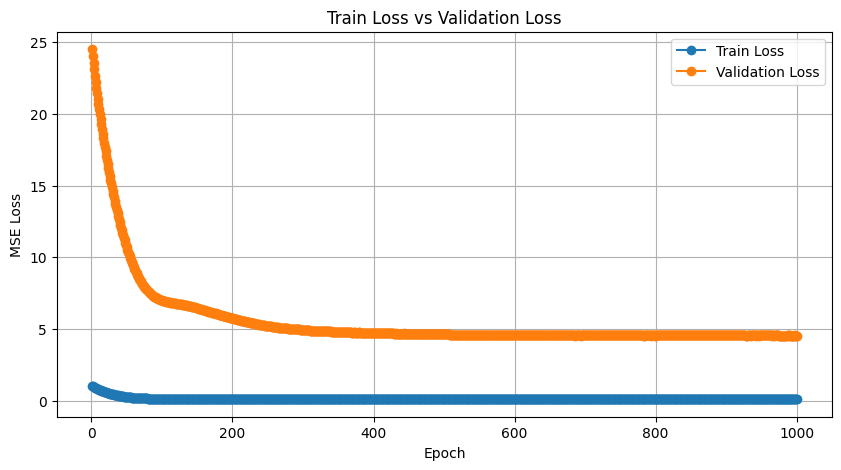

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(range(1, num_epochs + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, num_epochs + 1), val_losses, marker="o", label="Validation Loss")

plt.title("Train Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

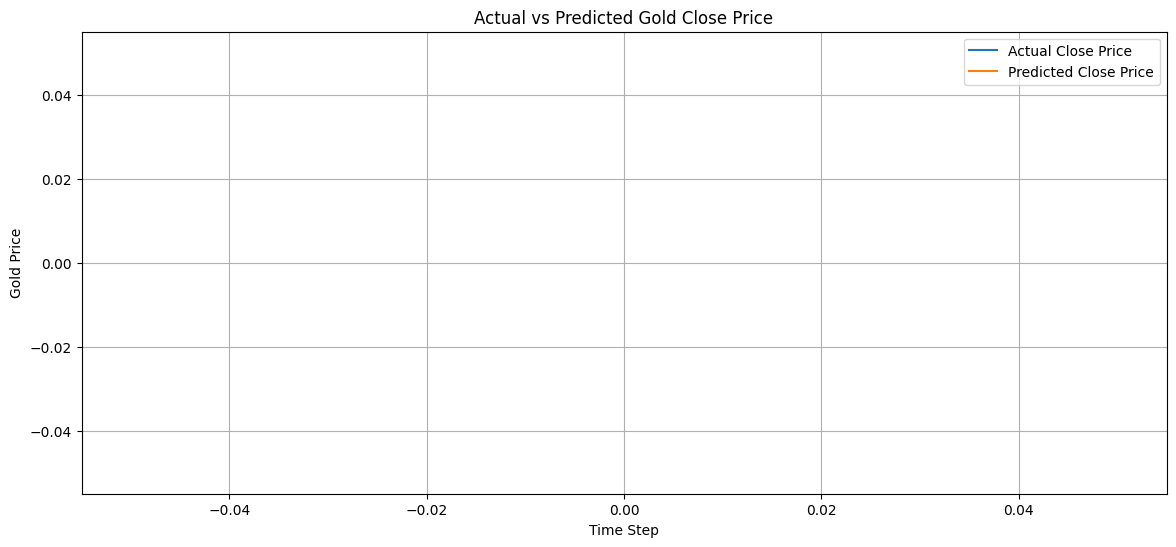

In [19]:
def get_predictions(model, data_loader, device, target_mean, target_std):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            pred , _ = model(x_batch)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    # Inverse normalize
    all_preds = all_preds * target_std + target_mean
    all_targets = all_targets * target_std + target_mean
    return all_preds, all_targets


#val dataset check
preds, targets = get_predictions(
    model=model,
    data_loader=test_loader,
    device=device,
    target_mean=target_mean,
    target_std=target_std
)
plt.figure(figsize=(14, 6))

plt.plot(targets[n-20:], label="Actual Close Price")
plt.plot(preds[n-20:], label="Predicted Close Price")

plt.title("Actual vs Predicted Gold Close Price")
plt.xlabel("Time Step")
plt.ylabel("Gold Price")
plt.legend()
plt.grid(True)
plt.show()


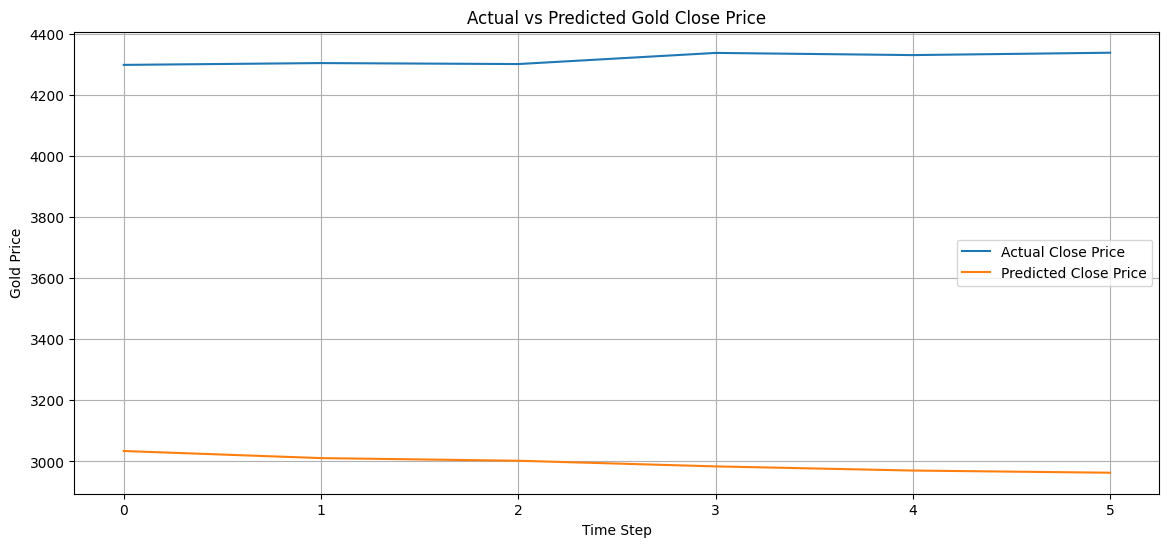

In [20]:
def get_predictions(model, data_loader, device, target_mean, target_std):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            pred, _ = model(x_batch)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    # Inverse normalize
    all_preds = all_preds * target_std + target_mean
    all_targets = all_targets * target_std + target_mean

    return all_preds, all_targets


#val dataset check
preds, targets = get_predictions(
    model=model,
    data_loader=test_loader,
    device=device,
    target_mean=target_mean,
    target_std=target_std
)
plt.figure(figsize=(14, 6))

plt.plot(targets, label="Actual Close Price")
plt.plot(preds, label="Predicted Close Price")

plt.title("Actual vs Predicted Gold Close Price")
plt.xlabel("Time Step")
plt.ylabel("Gold Price")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
import numpy as np
import torch

def get_xgboost_features(model, data_loader, device):
    model.eval()

    features_list = []
    labels_list = []

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(device)
            ffn_out, _ = model.extract_features(x_batch)
            norm_features = model.fc[0](ffn_out)
            features_list.append(norm_features.detach().cpu().numpy())
            labels_list.append(y_batch.detach().cpu().numpy())

    X = np.vstack(features_list)
    y = np.concatenate(labels_list, axis=0)
    y = y.reshape(-1)

    return X, y

In [22]:
import numpy as np
from xgboost import XGBRegressor
X_train_xgb, y_train_xgb = get_xgboost_features(model, train_loader, device)
X_test_xgb, y_test_xgb = get_xgboost_features(model, test_loader, device)
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    device="cpu",
    random_state=42
)

xgb_model.fit(
    X_train_xgb,
    y_train_xgb,
    eval_set=[(X_test_xgb, y_test_xgb)],
    verbose=50
)

[0]	validation_0-rmse:4.68079
[50]	validation_0-rmse:3.34883
[100]	validation_0-rmse:3.01484
[150]	validation_0-rmse:2.97938
[200]	validation_0-rmse:2.97219
[250]	validation_0-rmse:2.97068
[300]	validation_0-rmse:2.96837
[350]	validation_0-rmse:2.96880
[400]	validation_0-rmse:2.96908
[450]	validation_0-rmse:2.96926
[500]	validation_0-rmse:2.96966
[550]	validation_0-rmse:2.96947
[600]	validation_0-rmse:2.97065
[650]	validation_0-rmse:2.97000
[700]	validation_0-rmse:2.97046
[750]	validation_0-rmse:2.96971
[800]	validation_0-rmse:2.96868
[850]	validation_0-rmse:2.96866
[900]	validation_0-rmse:2.96881
[950]	validation_0-rmse:2.96857
[999]	validation_0-rmse:2.96851


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device='cpu', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [23]:
y_pred = xgb_model.predict(X_test_xgb)

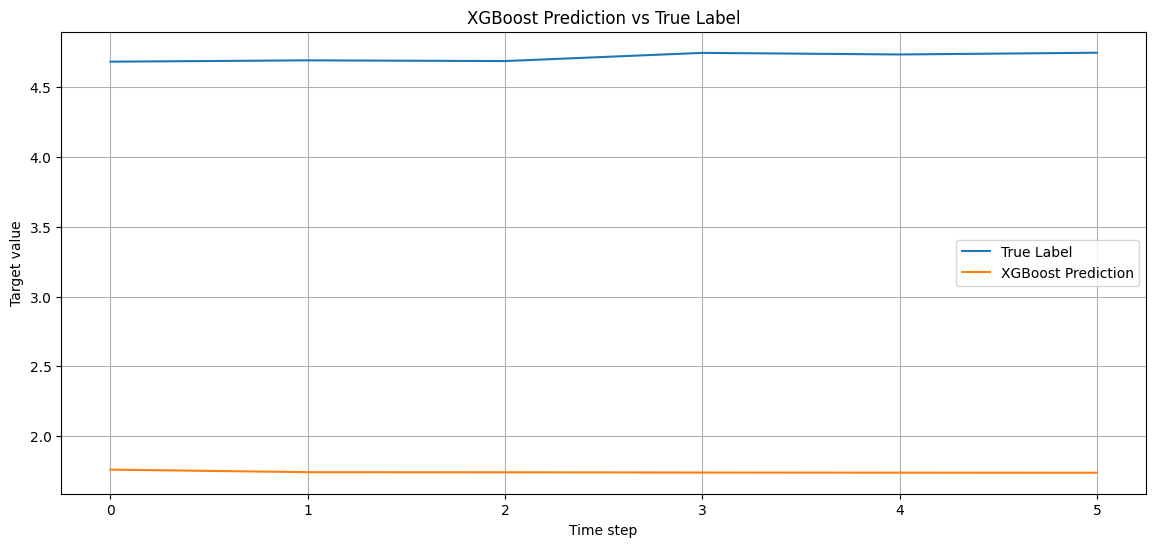

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(y_test_xgb, label="True Label")
plt.plot(y_pred, label="XGBoost Prediction")

plt.title("XGBoost Prediction vs True Label")
plt.xlabel("Time step")
plt.ylabel("Target value")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import pandas as pd
label = pd.read_csv('/kaggle/input/datasets/wangszhi/raw-datasets/Gold_price.csv')
feature1 = pd.read_csv('/kaggle/input/datasets/wangszhi/raw-datasets/REAINTRATREARAT10Y.csv')
feature2 = pd.read_csv('/kaggle/input/datasets/wangszhi/raw-datasets/filtered_data.csv')
feature3 = pd.read_csv('/kaggle/input/datasets/wangszhi/additional-dataset/UNRATE.csv')
feature4 = pd.read_csv('//kaggle/input/datasets/wangszhi/additional-dataset/income.csv')
# feature3 = pd.read_csv('/kaggle/input/datasets/wangszhi/raw-datasets/us-dollar-index.csv')

In [ ]:
print(f"The size of label: {len(label)}")
print(f"The size of feature1: {len(feature1)}")
print(f"The size of feature2: {len(feature2)}")
print(f"The size of feature3: {len(feature3)}")
print(f"The size of feature4: {len(feature4)}")
# print(f"The size of feature3: {len(feature3)}")

new_label = label[80:] 
print(new_label)

In [ ]:
new_label = label[804:-1] 
new_feature1 = feature1[:-1]
new_feature2= feature2[1788:]
new_feature3= feature3[408:]

print(f"The size of label: {len(new_label)}")
print(f"The size of feature1: {len(new_feature1)}")
print(f"The size of feature2: {len(new_feature2)}")
print(f"The size of feature2: {len(new_feature3)}")
print(new_label)
print(new_feature1)
print(new_feature2)
print(new_feature3)

# new_feature3 = 

In [ ]:
#merge a new dataframe
new_feature1_processed = new_feature1.drop("observation_date",axis=1)
new_feature2_processed = new_feature2.drop("Date",axis=1)
new_feature3_processed = new_feature3.drop("observation_date",axis=1)
print(new_feature1_processed)
print(new_feature2_processed)
print(new_feature3_processed)

In [ ]:
new_label = new_label.reset_index(drop=True)
new_feature1_processed = new_feature1_processed.reset_index(drop=True)
new_feature2_processed = new_feature2_processed.reset_index(drop=True)
new_feature3_processed = new_feature3_processed.reset_index(drop=True)

df_processed = pd.concat([new_feature1_processed, new_feature2_processed,new_feature3_processed ,new_label],axis=1, ignore_index=True)


In [ ]:
df_processed

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation(df, selected_columns=None):
    if selected_columns:
        data_to_corr = df[selected_columns]
    corr_matrix = data_to_corr.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, 
                annot=True,      
                fmt=".2f",       
                cmap='coolwarm', 
                linewidths=0.5)  
    
    plt.title('Ma trận tương quan giữa các thuộc tính')
    plt.show()

cols_to_check = [0, 1, 2, 4 ]
plot_correlation(df_processed, selected_columns=cols_to_check)
